# Linear + MLP Position Probes
Trains both a **linear** and a **shallow MLP** probe on the frozen GRU hidden state
and compares their ability to decode 2D object positions.

Two matching modes (`USE_HUNGARIAN`):
- `True`  — Hungarian matching; use with **random reflectivities** datasets.
- `False` — Direct MSE on fixed object order; use with **fixed_reflectivities** datasets.

The linear probe uses an exact least-squares solve when `USE_HUNGARIAN=False`;
both probes use gradient descent when `USE_HUNGARIAN=True`.

In [30]:
import sys

sys.path.insert(0, ".")

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPoly
from tqdm.notebook import tqdm

import helpers.nb_utils as nb_utils
import helpers.nb_viz as nb_viz

## Config — edit these

In [ ]:
CHECKPOINT_PATH = "../runs/2_dset3_gru_persistentids_inview/best_model.pt"
TRAIN_H5_PATH = "../datasets/3_fixed_refl_inview_brighter_train/dataset.h5"
TEST_H5_PATH = "../datasets/3_fixed_refl_inview_brighter_eval/dataset.h5"

NUM_EXTRACTOR_TRAIN = 10_000
DEVICE = "cuda"
BATCH_SIZE = 256
NUM_WORKERS = 12
LR = 1e-3
N_EPOCHS = 30
MLP_HIDDEN = 128

# True  → Hungarian matching (random reflectivities dataset)
# False → Direct MSE on fixed object order (fixed_reflectivities dataset)
USE_HUNGARIAN = False

# True  → autoregressive rollout (model feeds its own predictions after NUM_OBS steps)
# False → teacher forcing (ground-truth observations at every step)
USE_AUTOREGRESSIVE = False
NUM_OBS = 10  # context steps before AR rollout begins (only used when USE_AUTOREGRESSIVE=True)

# Probe colors used in comparison plots
LINEAR_COLOR = "#0072B2"  # Okabe-Ito blue
MLP_COLOR = "#D55E00"  # Okabe-Ito vermilion

## Load frozen GRU

In [32]:
model, ckpt_info = nb_utils.load_model(CHECKPOINT_PATH, DEVICE)
hidden_size = ckpt_info["model_config"]["hidden_size"]

print(f"GRU epoch    : {ckpt_info['epoch']}")
print(f"GRU val loss : {ckpt_info['val_loss']:.6f}")
print(f"Hidden size  : {hidden_size}")

with h5py.File(TRAIN_H5_PATH, "r") as f:
    n_total = f["obs_intensity"].shape[0]
    max_obj = f["positions"].shape[2]
    T_frames = f["obs_intensity"].shape[1]

print(f"\nDataset      : {n_total:,} samples, T={T_frames}, max_obj={max_obj}")

rng = np.random.default_rng(42)
train_idx = rng.choice(n_total, size=min(NUM_EXTRACTOR_TRAIN, n_total), replace=False)
print(f"Probe train  : {len(train_idx):,} samples")

GRU epoch    : 50
GRU val loss : 0.023733
Hidden size  : 256

Dataset      : 100,000 samples, T=40, max_obj=2
Probe train  : 10,000 samples


In [ ]:
# ── Hidden-state extraction helper ────────────────────────────────────────────
# Wraps teacher-forcing and autoregressive rollout behind a single call.
# All callers below use _get_h(model, obs, DEVICE) — swap USE_AUTOREGRESSIVE
# in the config cell to change which mode every cell uses.


@torch.no_grad()
def _get_hidden_states_ar(model, obs, device, num_obs):
    """Autoregressive rollout.

    Teacher-forces the first *num_obs* steps, then feeds the model's own
    predicted observation back as input for the remaining steps.

    Parameters
    ----------
    obs : (B, T, R) float tensor
    num_obs : int  — steps of ground-truth context before AR begins

    Returns
    -------
    h : (B, T-1, H)  hidden states at each step (same shape as teacher-forcing)
    """
    obs = obs.to(device)
    B, T, R = obs.shape
    h_list, gru_h, pred = [], None, None
    for t in range(T - 1):
        inp = obs[:, t, :] if t < num_obs else pred
        x = F.relu(model.encoder(inp)).unsqueeze(1)  # (B, 1, enc_dim)
        h_out, gru_h = model.gru(x, gru_h)  # (B, 1, H)
        h_list.append(h_out.squeeze(1))  # (B, H)
        pred = model.decoder(h_out.squeeze(1))  # (B, R)  next-step prediction
    return torch.stack(h_list, dim=1)  # (B, T-1, H)


def _get_h(model, obs, device):
    """Return hidden states using the mode set by USE_AUTOREGRESSIVE."""
    if USE_AUTOREGRESSIVE:
        return _get_hidden_states_ar(model, obs, device, NUM_OBS)
    return nb_utils.get_hidden_states(model, obs, device)


mode_str_ar = f"AR(ctx={NUM_OBS})" if USE_AUTOREGRESSIVE else "TF"
print(f"Hidden-state mode: {mode_str_ar}")

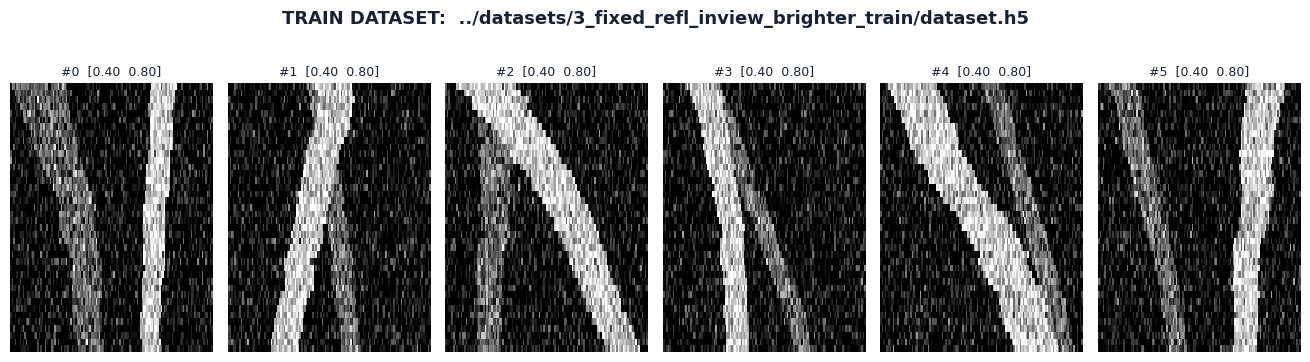

In [33]:
# ── Dataset sanity check — waterfall grid ────────────────────────────────────
from pim.viz import make_waterfall

N_SANITY = 6
fig, axes = plt.subplots(
    1, N_SANITY, figsize=(N_SANITY * 2.2, 3.5), facecolor=nb_viz._BG_HEX
)
fig.suptitle(
    f"TRAIN DATASET:  {TRAIN_H5_PATH}",
    fontsize=13,
    fontweight="bold",
    color=nb_viz._TEXT_COLOR,
    y=1.02,
)

for ax, idx in zip(axes, range(N_SANITY)):
    scene, obs_depth, obs_id, obs_intensity = nb_utils.load_sample(TRAIN_H5_PATH, idx)
    wf = make_waterfall(obs_depth, obs_id, obs_intensity, scene)
    ax.imshow(wf, aspect="auto", origin="upper", interpolation="nearest")
    refl_str = "  ".join(f"{r:.2f}" for r in scene.reflectivities)
    ax.set_title(f"#{idx}  [{refl_str}]", color=nb_viz._TEXT_COLOR, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

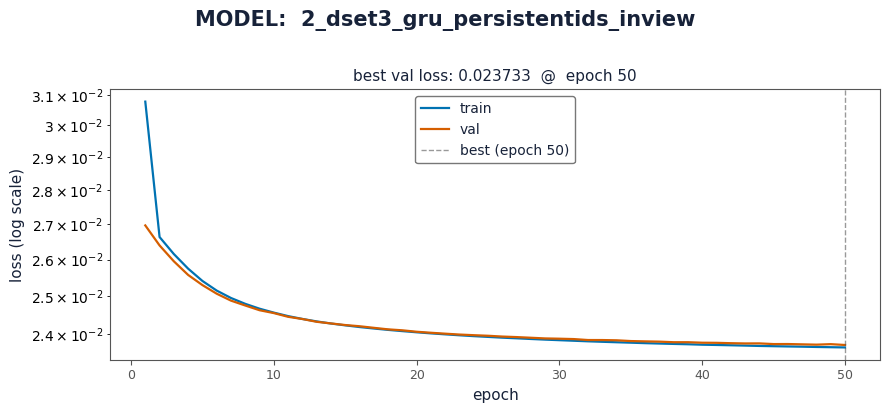

In [34]:
# ── GRU training curve ────────────────────────────────────────────────────────
import json
from pathlib import Path

metrics_path = Path(CHECKPOINT_PATH).parent / "metrics.jsonl"
metrics = [
    json.loads(line) for line in metrics_path.read_text().splitlines() if line.strip()
]

epochs = [m["epoch"] for m in metrics]
train_loss = [m["train_loss"] for m in metrics]
val_loss = [m["val_loss"] for m in metrics]
best_epoch = ckpt_info["epoch"]
run_name = Path(CHECKPOINT_PATH).parent.name

fig, ax = plt.subplots(figsize=(9, 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)

ax.plot(epochs, train_loss, color=LINEAR_COLOR, linewidth=1.6, label="train")
ax.plot(epochs, val_loss, color=MLP_COLOR, linewidth=1.6, label="val")
ax.axvline(
    best_epoch,
    color=nb_viz._TICK_COLOR,
    linewidth=1.0,
    linestyle="--",
    alpha=0.6,
    label=f"best (epoch {best_epoch})",
)

ax.set_yscale("log")
ax.set_xlabel("epoch", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel("loss (log scale)", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title(
    f"best val loss: {ckpt_info['val_loss']:.6f}  @  epoch {best_epoch}",
    color=nb_viz._TEXT_COLOR,
    fontsize=11,
)
ax.legend(
    labelcolor=nb_viz._TEXT_COLOR,
    facecolor=nb_viz._BG_HEX,
    edgecolor=nb_viz._TICK_COLOR,
    fontsize=10,
)

fig.suptitle(
    f"MODEL:  {run_name}",
    fontsize=15,
    fontweight="bold",
    color=nb_viz._TEXT_COLOR,
    y=1.02,
)

plt.tight_layout()
plt.show()

## Linear probe

In [35]:
class LinearExtractor(nn.Module):
    """hidden_size → (max_obj, 2) via a single linear layer."""

    def __init__(self, hidden_size: int, max_obj: int) -> None:
        super().__init__()
        self.linear = nn.Linear(hidden_size, max_obj * 2)
        self.max_obj = max_obj

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.linear(h).reshape(*h.shape[:-1], self.max_obj, 2)


linear_extractor = LinearExtractor(hidden_size, max_obj).to(DEVICE)
linear_optimizer = torch.optim.Adam(linear_extractor.parameters(), lr=LR)
print(
    f"Linear extractor params: {sum(p.numel() for p in linear_extractor.parameters()):,}"
)

Linear extractor params: 1,028


### Train linear probe

In [ ]:
def hungarian_mse(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    loss_01 = ((pred - target) ** 2).mean(dim=(1, 2))
    loss_10 = ((pred - target[:, [1, 0], :]) ** 2).mean(dim=(1, 2))
    return torch.minimum(loss_01, loss_10).mean()


train_loader = nb_utils.build_loader(
    TRAIN_H5_PATH,
    train_idx,
    keys=("obs_intensity", "positions", "is_visible"),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
)

if USE_HUNGARIAN:
    # ── Gradient descent ────────────────────────────────────────────────────
    linear_losses = []
    for epoch in tqdm(range(1, N_EPOCHS + 1), desc="linear epochs"):
        linear_extractor.train()
        running, n_batches = 0.0, 0
        for batch in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
            obs = batch["obs_intensity"].to(DEVICE)
            pos = batch["positions"].to(DEVICE)
            vis = batch["is_visible"].bool().to(DEVICE)
            B, T = obs.shape[0], obs.shape[1]
            h = _get_h(model, obs, DEVICE)
            vis_t = vis[:, :-1, :]
            pos_t = pos[:, :-1, :, :]
            all_vis = vis_t.all(dim=2)
            h_flat = h.reshape(B * (T - 1), hidden_size)
            pos_flat = pos_t.reshape(B * (T - 1), max_obj, 2)
            mask = all_vis.reshape(B * (T - 1))
            if mask.sum() == 0:
                continue
            pred = linear_extractor(h_flat[mask])
            loss = hungarian_mse(pred, pos_flat[mask])
            linear_optimizer.zero_grad()
            loss.backward()
            linear_optimizer.step()
            running += loss.item()
            n_batches += 1
        linear_losses.append(running / n_batches if n_batches else float("nan"))
    print(f"\nLinear final train loss: {linear_losses[-1]:.6f}")

else:
    # ── Exact least-squares ──────────────────────────────────────────────────
    all_h, all_pos = [], []
    linear_extractor.eval()
    with torch.no_grad():
        for batch in tqdm(train_loader, desc="collecting hidden states"):
            obs = batch["obs_intensity"].to(DEVICE)
            pos = batch["positions"].to(DEVICE)
            vis = batch["is_visible"].bool().to(DEVICE)
            B, T = obs.shape[0], obs.shape[1]
            h = _get_h(model, obs, DEVICE)
            vis_t = vis[:, :-1, :]
            pos_t = pos[:, :-1, :, :]
            all_vis = vis_t.all(dim=2)
            h_flat = h.reshape(B * (T - 1), hidden_size).cpu().numpy()
            pos_flat = pos_t.reshape(B * (T - 1), max_obj * 2).cpu().numpy()
            mask = all_vis.reshape(B * (T - 1)).cpu().numpy()
            all_h.append(h_flat[mask])
            all_pos.append(pos_flat[mask])
    X = np.concatenate(all_h, axis=0)
    Y = np.concatenate(all_pos, axis=0)
    X_aug = np.concatenate([X, np.ones((len(X), 1), dtype=X.dtype)], axis=1)
    W, _, rank, _ = np.linalg.lstsq(X_aug, Y, rcond=None)
    with torch.no_grad():
        linear_extractor.linear.weight.copy_(torch.from_numpy(W[:-1].T).float())
        linear_extractor.linear.bias.copy_(torch.from_numpy(W[-1]).float())
    train_mse = np.mean((X_aug @ W - Y) ** 2)
    print(
        f"Exact regression: {len(X):,} frames  |  rank {rank}  |  train MSE {train_mse:.6f}"
    )

In [37]:
if USE_HUNGARIAN:
    loss_label = "MSE (matched)"
    fig, ax = plt.subplots(figsize=(8, 4), facecolor=nb_viz._BG_HEX)
    nb_viz.style_ax(ax)
    ax.plot(range(1, N_EPOCHS + 1), linear_losses, color=LINEAR_COLOR, linewidth=1.8)
    ax.set_xlabel("epoch", color=nb_viz._TEXT_COLOR, fontsize=11)
    ax.set_ylabel(loss_label, color=nb_viz._TEXT_COLOR, fontsize=11)
    ax.set_title("Linear probe — training loss", color=nb_viz._TEXT_COLOR, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    loss_label = "MSE (direct)"
    print("Exact regression — no epoch curve.")

Exact regression — no epoch curve.


## MLP probe

In [38]:
class MLPExtractor(nn.Module):
    """hidden_size → MLP_HIDDEN (ReLU) → (max_obj, 2)."""

    def __init__(self, hidden_size: int, mlp_hidden: int, max_obj: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, max_obj * 2),
        )
        self.max_obj = max_obj

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        return self.net(h).reshape(*h.shape[:-1], self.max_obj, 2)


mlp_extractor = MLPExtractor(hidden_size, MLP_HIDDEN, max_obj).to(DEVICE)
mlp_optimizer = torch.optim.Adam(mlp_extractor.parameters(), lr=LR)
print(f"MLP extractor params : {sum(p.numel() for p in mlp_extractor.parameters()):,}")
print(f"Architecture         : {hidden_size} → {MLP_HIDDEN} → {max_obj * 2}")

MLP extractor params : 33,412
Architecture         : 256 → 128 → 4


### Train MLP probe

In [ ]:
mlp_losses = []
for epoch in tqdm(range(1, N_EPOCHS + 1), desc="MLP epochs"):
    mlp_extractor.train()
    running, n_batches = 0.0, 0
    for batch in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
        obs = batch["obs_intensity"].to(DEVICE)
        pos = batch["positions"].to(DEVICE)
        vis = batch["is_visible"].bool().to(DEVICE)
        B, T = obs.shape[0], obs.shape[1]
        h = _get_h(model, obs, DEVICE)
        vis_t = vis[:, :-1, :]
        pos_t = pos[:, :-1, :, :]
        all_vis = vis_t.all(dim=2)
        h_flat = h.reshape(B * (T - 1), hidden_size)
        pos_flat = pos_t.reshape(B * (T - 1), max_obj, 2)
        mask = all_vis.reshape(B * (T - 1))
        if mask.sum() == 0:
            continue
        pred = mlp_extractor(h_flat[mask])
        if USE_HUNGARIAN:
            loss = hungarian_mse(pred, pos_flat[mask])
        else:
            loss = F.mse_loss(pred, pos_flat[mask])
        mlp_optimizer.zero_grad()
        loss.backward()
        mlp_optimizer.step()
        running += loss.item()
        n_batches += 1
    mlp_losses.append(running / n_batches if n_batches else float("nan"))

print(f"\nMLP final train loss: {mlp_losses[-1]:.6f}")

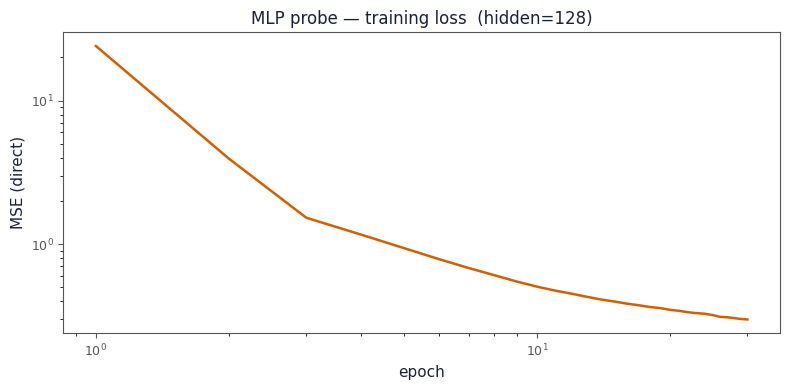

In [40]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.plot(range(1, N_EPOCHS + 1), mlp_losses, color=MLP_COLOR, linewidth=1.8)
ax.set_xlabel("epoch", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel(loss_label, color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title(
    f"MLP probe — training loss  (hidden={MLP_HIDDEN})",
    color=nb_viz._TEXT_COLOR,
    fontsize=12,
)
ax.set_xscale("log")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Evaluation on test set

In [ ]:
test_loader = nb_utils.build_loader(
    TEST_H5_PATH,
    indices=None,
    keys=("obs_intensity", "positions", "is_visible"),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

linear_extractor.eval()
mlp_extractor.eval()

linear_per_t_sum = np.zeros(T_frames - 1)
linear_per_t_count = np.zeros(T_frames - 1)
linear_per_obj_sum = np.zeros(max_obj)
mlp_per_t_sum = np.zeros(T_frames - 1)
mlp_per_obj_sum = np.zeros(max_obj)
per_obj_count = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="test eval"):
        obs = batch["obs_intensity"].to(DEVICE)
        pos = batch["positions"].to(DEVICE)
        vis = batch["is_visible"].bool().to(DEVICE)
        B, T = obs.shape[0], obs.shape[1]
        h = _get_h(model, obs, DEVICE)  # one pass, shared by both probes
        vis_t = vis[:, :-1, :]
        pos_t = pos[:, :-1, :, :]
        all_vis = vis_t.all(dim=2)
        h_flat = h.reshape(B * (T - 1), hidden_size)
        pos_flat = pos_t.reshape(B * (T - 1), max_obj, 2)
        mask = all_vis.reshape(B * (T - 1))
        t_idx = (
            torch.arange(T - 1, device=DEVICE).unsqueeze(0).expand(B, -1).reshape(-1)
        )
        if mask.sum() == 0:
            continue
        gt_pos = pos_flat[mask]
        t_vis = t_idx[mask].cpu().numpy()

        for extractor, per_t_sum, per_obj_sum in [
            (linear_extractor, linear_per_t_sum, linear_per_obj_sum),
            (mlp_extractor, mlp_per_t_sum, mlp_per_obj_sum),
        ]:
            pred = extractor(h_flat[mask])
            if USE_HUNGARIAN:
                loss_01 = ((pred - gt_pos) ** 2).mean(dim=(1, 2))
                loss_10 = ((pred - gt_pos[:, [1, 0], :]) ** 2).mean(dim=(1, 2))
                per_sample_mse = torch.minimum(loss_01, loss_10).cpu().numpy()
                swap = loss_10 < loss_01
                gt_matched = torch.where(
                    swap[:, None, None], gt_pos[:, [1, 0], :], gt_pos
                )
            else:
                per_sample_mse = ((pred - gt_pos) ** 2).mean(dim=(1, 2)).cpu().numpy()
                gt_matched = gt_pos
            per_obj_batch = ((pred - gt_matched) ** 2).mean(dim=2).cpu().numpy()
            per_obj_sum += per_obj_batch.sum(axis=0)
            np.add.at(per_t_sum, t_vis, per_sample_mse)

        per_obj_count += mask.sum().item()
        np.add.at(linear_per_t_count, t_vis, 1)

mlp_per_t_count = linear_per_t_count.copy()  # masks are identical
linear_per_t_mse = np.where(
    linear_per_t_count > 0, linear_per_t_sum / linear_per_t_count, np.nan
)
mlp_per_t_mse = np.where(mlp_per_t_count > 0, mlp_per_t_sum / mlp_per_t_count, np.nan)
linear_per_obj_mse = linear_per_obj_sum / max(per_obj_count, 1)
mlp_per_obj_mse = mlp_per_obj_sum / max(per_obj_count, 1)

mode_str = "matched" if USE_HUNGARIAN else "direct"
print(f"Hidden-state mode: {mode_str_ar}")
print(f"Linear — overall MSE ({mode_str}): {np.nanmean(linear_per_t_mse):.6f}")
for i in range(max_obj):
    print(f"  Object {i}: {linear_per_obj_mse[i]:.6f}")
print(f"MLP    — overall MSE ({mode_str}): {np.nanmean(mlp_per_t_mse):.6f}")
for i in range(max_obj):
    print(f"  Object {i}: {mlp_per_obj_mse[i]:.6f}")

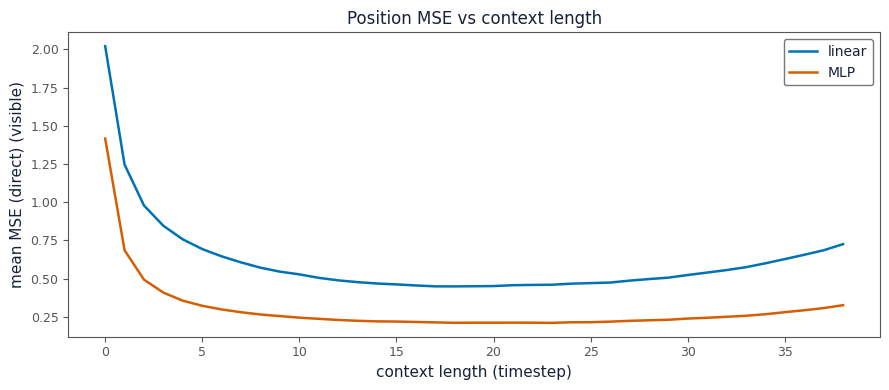

In [42]:
# ── MSE vs context length ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.plot(
    range(T_frames - 1),
    linear_per_t_mse,
    color=LINEAR_COLOR,
    linewidth=1.8,
    label="linear",
)
ax.plot(range(T_frames - 1), mlp_per_t_mse, color=MLP_COLOR, linewidth=1.8, label="MLP")
ax.set_xlabel("context length (timestep)", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel(f"mean {loss_label} (visible)", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title("Position MSE vs context length", color=nb_viz._TEXT_COLOR, fontsize=12)
ax.legend(
    labelcolor=nb_viz._TEXT_COLOR,
    facecolor=nb_viz._BG_HEX,
    edgecolor=nb_viz._TICK_COLOR,
    fontsize=10,
)
plt.tight_layout()
plt.show()

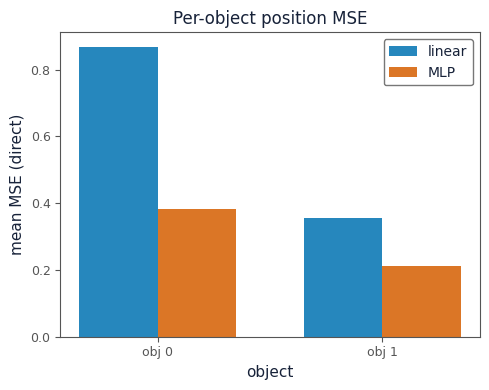

In [43]:
# ── Per-object MSE bar chart ──────────────────────────────────────────────────
x = np.arange(max_obj)
width = 0.35

fig, ax = plt.subplots(figsize=(max(5, max_obj * 2), 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.bar(
    x - width / 2,
    linear_per_obj_mse,
    width,
    label="linear",
    color=LINEAR_COLOR,
    alpha=0.85,
)
ax.bar(x + width / 2, mlp_per_obj_mse, width, label="MLP", color=MLP_COLOR, alpha=0.85)
ax.set_xlabel("object", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel(f"mean {loss_label}", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title("Per-object position MSE", color=nb_viz._TEXT_COLOR, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"obj {i}" for i in range(max_obj)])
ax.legend(
    labelcolor=nb_viz._TEXT_COLOR,
    facecolor=nb_viz._BG_HEX,
    edgecolor=nb_viz._TICK_COLOR,
    fontsize=10,
)
plt.tight_layout()
plt.show()

## Single-sample visualization

In [ ]:
from pim.sim import Scene

# Visualization
VIZ_SAMPLE_IDX = 1

scene, obs_depth, obs_id, obs_intensity = nb_utils.load_sample(
    TEST_H5_PATH, VIZ_SAMPLE_IDX
)

with h5py.File(TEST_H5_PATH, "r") as f:
    vis_sample = f["is_visible"][VIZ_SAMPLE_IDX].astype(bool)
    pos_sample = f["positions"][VIZ_SAMPLE_IDX].astype(np.float32)

obs_t = torch.from_numpy(obs_intensity).float().unsqueeze(0).to(DEVICE)

linear_extractor.eval()
mlp_extractor.eval()
with torch.no_grad():
    h_sample = _get_h(model, obs_t, DEVICE)  # (1, T-1, H)
    linear_pred_pos = (
        linear_extractor(h_sample.squeeze(0)).cpu().numpy()
    )  # (T-1, max_obj, 2)
    mlp_pred_pos = mlp_extractor(h_sample.squeeze(0)).cpu().numpy()

gt_pos = pos_sample[:-1]  # (T-1, max_obj, 2)
vis_tm1 = vis_sample[:-1]  # (T-1, max_obj)
all_vis = vis_tm1.all(axis=1)
timesteps = np.arange(T_frames - 1)


# per-object MSE for each probe
def _sample_per_obj_mse(pred, gt, vis_mask, use_hungarian):
    if use_hungarian and vis_mask.any():
        err_01 = ((pred[vis_mask] - gt[vis_mask]) ** 2).mean()
        err_10 = ((pred[vis_mask] - gt[vis_mask][:, [1, 0], :]) ** 2).mean()
        gt_m = gt if err_01 <= err_10 else gt[:, [1, 0], :]
    else:
        gt_m = gt
    return np.array(
        [
            (
                ((pred[vis_mask, i] - gt_m[vis_mask, i]) ** 2).mean()
                if vis_mask.any()
                else np.nan
            )
            for i in range(pred.shape[1])
        ]
    )


linear_sample_mse = _sample_per_obj_mse(linear_pred_pos, gt_pos, all_vis, USE_HUNGARIAN)
mlp_sample_mse = _sample_per_obj_mse(mlp_pred_pos, gt_pos, all_vis, USE_HUNGARIAN)

print(
    f"Sample {VIZ_SAMPLE_IDX} — hidden-state mode: {mode_str_ar}  |  matching: {mode_str}"
)
for i in range(max_obj):
    print(
        f"  Object {i}:  linear {linear_sample_mse[i]:.4f}   MLP {mlp_sample_mse[i]:.4f}"
    )

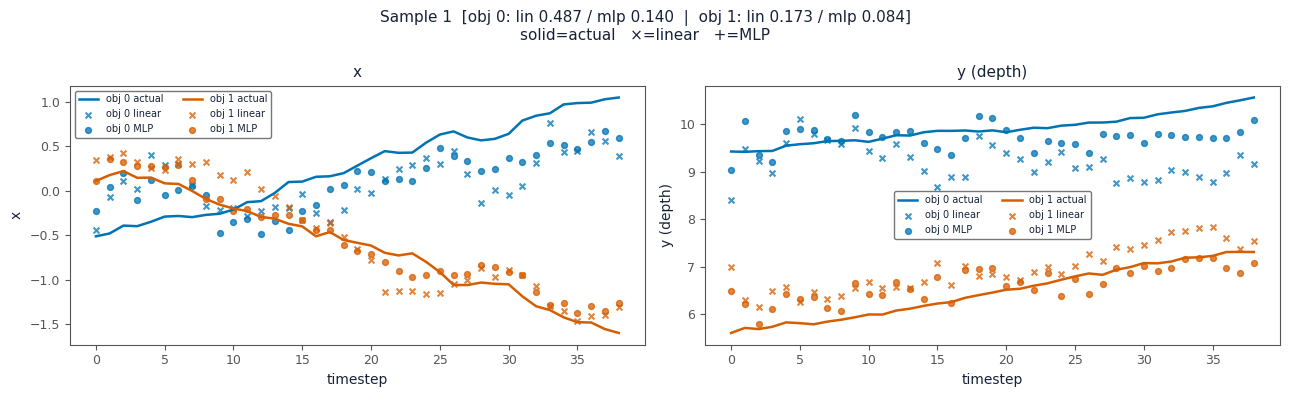

In [50]:
# ── Trajectory plot: GT + both probe predictions ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=nb_viz._BG_HEX)
mse_str = "  |  ".join(
    f"obj {i}: lin {linear_sample_mse[i]:.3f} / mlp {mlp_sample_mse[i]:.3f}"
    for i in range(max_obj)
)
fig.suptitle(
    f"Sample {VIZ_SAMPLE_IDX}  [{mse_str}]\n" "solid=actual   ×=linear   +=MLP",
    color=nb_viz._TEXT_COLOR,
    fontsize=11,
)

for ax, coord, label in zip(axes, [0, 1], ["x", "y (depth)"]):
    nb_viz.style_ax(ax)
    for obj in range(min(max_obj, scene.positions.shape[1])):
        color = nb_viz.plot_color(scene.colors[obj])
        vis_obj = vis_tm1[:, obj]
        ax.plot(
            timesteps,
            gt_pos[:, obj, coord],
            color=color,
            linewidth=1.8,
            label=f"obj {obj} actual",
        )
        ax.scatter(
            timesteps[vis_obj],
            linear_pred_pos[vis_obj, obj, coord],
            color=color,
            s=18,
            marker="x",
            alpha=0.75,
            label=f"obj {obj} linear",
        )
        ax.scatter(
            timesteps[vis_obj],
            mlp_pred_pos[vis_obj, obj, coord],
            color=color,
            s=18,
            marker="o",
            alpha=0.75,
            label=f"obj {obj} MLP",
        )
    ax.set_xlabel("timestep", color=nb_viz._TEXT_COLOR, fontsize=10)
    ax.set_ylabel(label, color=nb_viz._TEXT_COLOR, fontsize=10)
    ax.set_title(label, color=nb_viz._TEXT_COLOR, fontsize=11)
    ax.legend(
        labelcolor=nb_viz._TEXT_COLOR,
        facecolor=nb_viz._BG_HEX,
        edgecolor=nb_viz._TICK_COLOR,
        fontsize=7,
        ncol=2,
    )

plt.tight_layout()
plt.show()

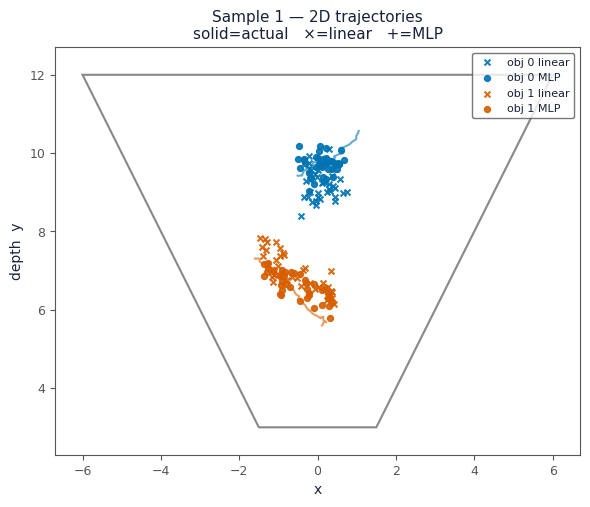

In [51]:
# ── 2D scene overlay ──────────────────────────────────────────────────────────
cfg = scene.config
fig, ax = plt.subplots(figsize=(6, 7), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.set_xlim(-cfg.x_far - 0.7, cfg.x_far + 0.7)
ax.set_ylim(cfg.y_near - 0.7, cfg.y_far + 0.7)
ax.set_aspect("equal")
ax.set_xlabel("x", color=nb_viz._TEXT_COLOR, fontsize=10)
ax.set_ylabel("depth  y", color=nb_viz._TEXT_COLOR, fontsize=10)
ax.set_title(
    f"Sample {VIZ_SAMPLE_IDX} — 2D trajectories\nsolid=actual   ×=linear   +=MLP",
    color=nb_viz._TEXT_COLOR,
    fontsize=11,
)

corners = np.array(
    [
        [-cfg.x_near, cfg.y_near],
        [cfg.x_near, cfg.y_near],
        [cfg.x_far, cfg.y_far],
        [-cfg.x_far, cfg.y_far],
    ]
)
ax.add_patch(
    MPoly(
        corners,
        closed=True,
        fill=False,
        edgecolor=nb_viz._FRUSTUM_EDGE,
        linewidth=1.5,
        zorder=1,
    )
)

for obj in range(min(max_obj, scene.positions.shape[1])):
    color = nb_viz.plot_color(scene.colors[obj])
    vis_obj = vis_tm1[:, obj]
    ax.plot(
        gt_pos[:, obj, 0],
        gt_pos[:, obj, 1],
        color=color,
        linewidth=1.5,
        alpha=0.6,
        zorder=2,
    )
    ax.scatter(
        linear_pred_pos[vis_obj, obj, 0],
        linear_pred_pos[vis_obj, obj, 1],
        color=color,
        s=18,
        marker="x",
        zorder=3,
        alpha=0.9,
        label=f"obj {obj} linear",
    )
    ax.scatter(
        mlp_pred_pos[vis_obj, obj, 0],
        mlp_pred_pos[vis_obj, obj, 1],
        color=color,
        s=18,
        marker="o",
        zorder=3,
        alpha=0.9,
        label=f"obj {obj} MLP",
    )

ax.legend(
    labelcolor=nb_viz._TEXT_COLOR,
    facecolor=nb_viz._BG_HEX,
    edgecolor=nb_viz._TICK_COLOR,
    fontsize=8,
    loc="upper right",
)
plt.tight_layout()
plt.show()